# **Documentation** for `eds-classification.jl`

## Import pacakges and functions

In [1]:
using CSV, DataFrames, Serialization, DecisionTree, MLJ
using StatsBase, Plots
include("./algorithms/edsClassification.jl");
include("./algorithms/categorical_histogram.jl");

## Check docstrings for a function
Replace the function name as needed.

In [2]:
println(@doc weber_classification)

```julia
weber_classification(data::DataFrame)
```

Random forest model for mineral identification

Takes a DataFrame of EDS net intensities for the elements Na, Mg, Al, Si, P, K, Ca, Ti, and Fe, then converts the DataFrame into an array of 23 elemental ratios to match the training features of the random forest model. The random forest model was trained on EDS net intensity data from 18 reference minerals acquired from the Smithsonian Institution. 

# REQUIRED ARGUMENTS

  * `data` :: DataFrame containing a column for each of the following elements: Na, Mg, Al, Si, P, K, Ca, Ti, and Fe. The name of each column may be the full element name or its abbreviation. For instance, "Silicon" and "Si" are valid table variable names. Both the American and British spelling of "Aluminum" ("Aluminium") are also valid. Capitalization is not required but spelling is paramount. The values in the table should represent the measured EDS net intensity for each element.

# RETURNS

A `NamedTuple`: (predici

## Load example EDS data sets

In [3]:
net = CSV.read("./data/eds_net_intensities.csv", DataFrame);
atp = CSV.read("./data/eds_atom_percents.csv", DataFrame);

## Apply algorithms to the appropriate data set

In [4]:
don = donarummo_classification(net);
kan = kandler_classification(atp);
kut = kutuzov_classification(atp);
pan = panta_classification(atp);
web = weber_classification(net);

## Visualize the mineral classification data
### Donarummo

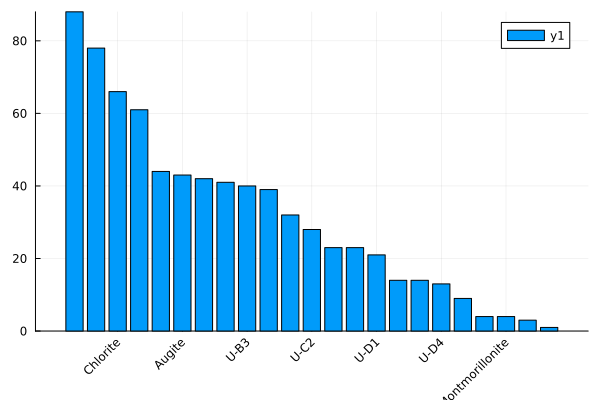

In [5]:
categorical_histogram(don[:,1], sortby=:descend, xrotation=45)

### Kandler

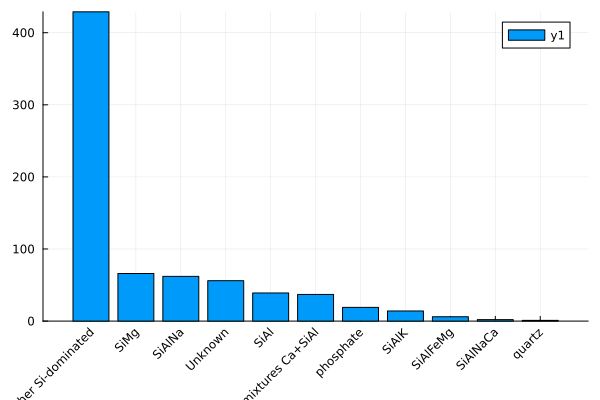

In [6]:
categorical_histogram(kan[:,1], sortby=:descend, xrotation=45)

### Kutuzov

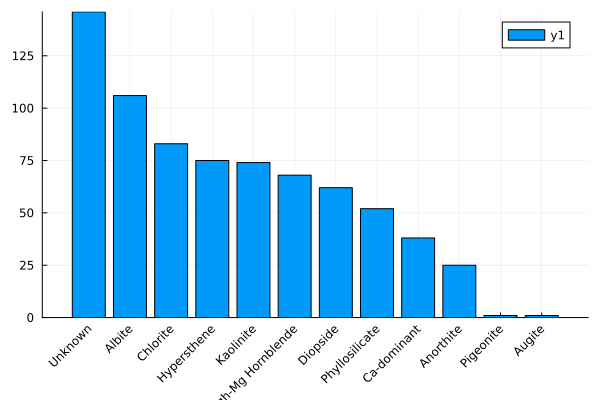

In [7]:
categorical_histogram(kut[:,1], sortby=:descend, xrotation=45)

### Panta

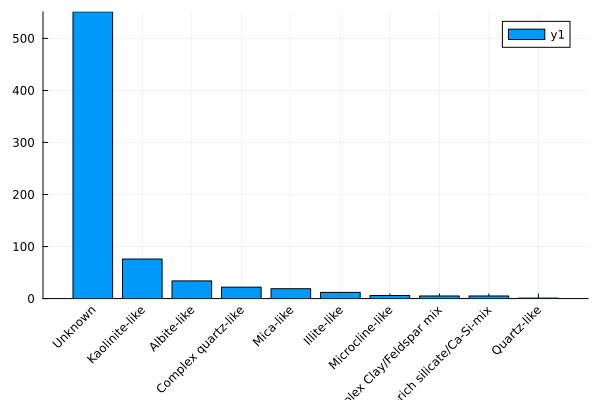

In [8]:
categorical_histogram(pan[:,1], sortby=:descend, xrotation=45)

### Weber

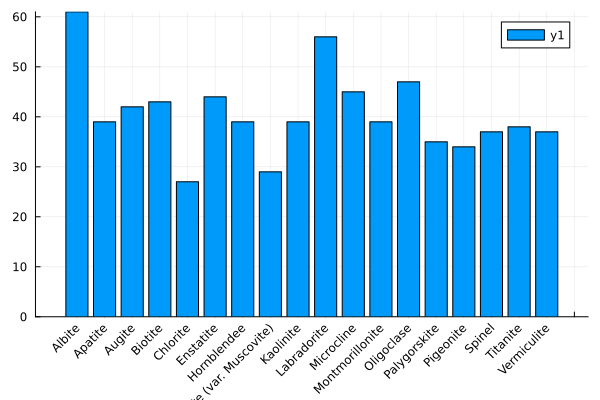

In [9]:
categorical_histogram(web.predicted_class, sortby=:descend, xrotation=45)

## Printing outputs for the Weber algorithm
### Example 1 - Find the mineral ID for an observation (i.e., row) and its associated probability score

In [10]:
observation = 485;
println("Weber prediction for mineral #485: \n", web.predicted_class[observation], "\n\nProbabilities:\n")
display(web.probabilities[observation,:])

Weber prediction for mineral #485: 
Illite (var. Muscovite)

Probabilities:



Row,Albite,Apatite,Augite,Biotite,Chlorite,Enstatite,Hornblendee,Illite (var. Muscovite),Kaolinite,Labradorite,Microcline,Montmorillonite,Oligoclase,Palygorskite,Pigeonite,Spinel,Titanite,Vermiculite
,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
485,0.0,0.0,0.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Example 2 - Compare the outputs of several algorithms

In [11]:
observation = 15;
println("Predictions for mineral #15:")
println("True mineral:    Albite")
println("Weber pred.:     ", web.predicted_class[observation])
println("Donarummo pred.: ", don[observation,1])
println("Kandler pred.    ", kan[observation,1])
println("Kutuzov pred.    ", kut[observation,1])
println("Panta pred.      ", pan[observation,1])

Predictions for mineral #15:
True mineral:    Albite
Weber pred.:     Albite
Donarummo pred.: Albite
Kandler pred.    SiAlNa
Kutuzov pred.    Albite
Panta pred.      Albite-like


---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*